### **가설검증 1+ 자치구별 공간 시각화 병합 및 시각화 분석**
#### 이전의 분석은 서울시 전체를 대상으로 하여 분석을 진행하였습니다. 서울시의 특정 지역 인구 밀집 등의 이유로 자치구별 분석 결과는 또 다른 결과가 도출될 수 있습니다.
#### 서울시의 각 자치구별로 PM 관련 교통사고 및 치명률에 대해서 면밀히 분석합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import geopandas as gpd         # geojson file read

# 시각화 시 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

****

#### **분석 1: 서울시 자치구별 PM 관련 교통사고 현황 시각화**
서울시의 경계선 지도 위에 PM 관련 교통사고 현황 데이터를 시각화합니다.

[geojson file 출처]

https://github.com/raqoon886/Local_HangJeongDong/blob/master/hangjeongdong_%EC%84%9C%EC%9A%B8%ED%8A%B9%EB%B3%84%EC%8B%9C.geojson

In [2]:
# 공간 데이터 로드 및 자치구 단위 병합
geo_data = gpd.read_file('hangjeongdong_서울특별시.geojson')
gu_geo_data = geo_data.dissolve(by='sggnm').reset_index()           # 'sggnm': 자치구(OO구)
gu_geo_data['sggnm'] = gu_geo_data['sggnm'].str.replace(" ", "")    # 자치구 공백 제거

# PM 교통사고 데이터 불러오기
df_acc = pd.read_csv('서울시 PM 교통사고 현황\서울시_자치구별_월별_PM교통사고.csv',
                      encoding='utf-8')
df_acc['연월'] = pd.to_datetime(df_acc['연월'])
df_acc['자치구'] = df_acc['자치구'].str.replace(" ", "")             # 자치구 공백 제거

In [3]:
# 자치구별 PM 사고 데이터 집계
df_acc_gu = df_acc.groupby('자치구')['PM_사고건수'].sum().reset_index()

# 공간 데이터와 분석 데이터 병합 (geo_data 대신 자치구 단위로 합친 gu_geo_data 사용)
merged_df = gu_geo_data.merge(df_acc_gu, left_on='sggnm', right_on='자치구', how='outer')

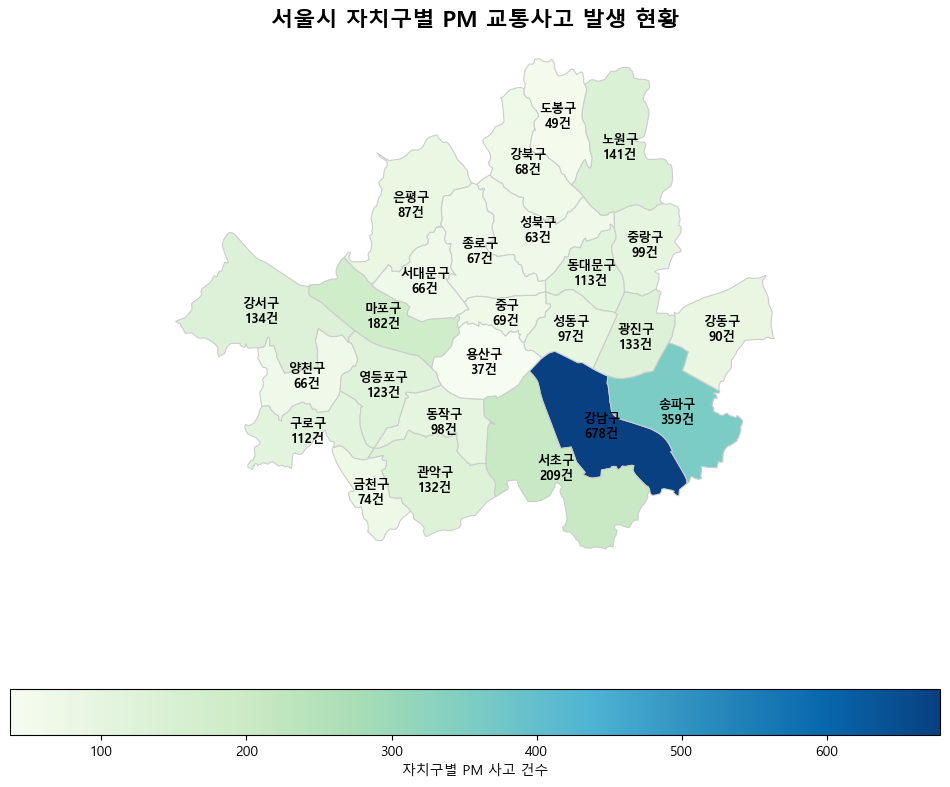

In [4]:
# 단계구분도(Choropleth Map) 시각화 및 라벨 추가
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

merged_df.plot(
    column='PM_사고건수', 
    cmap='GnBu', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='0.8', 
    legend=True,
    legend_kwds={'label': "자치구별 PM 사고 건수", 'orientation': "horizontal"}
)

# 텍스트 라벨 추가
for idx, row in merged_df.iterrows():
    if pd.notna(row['PM_사고건수']):
        # 표시할 텍스트 생성 (예: 강남구\n 500건)
        label_text = f"{row['sggnm']}\n{int(row['PM_사고건수'])}건"
        
        # 자치구 도형의 중심점 좌표 구하기
        centroid = row['geometry'].centroid
        
        # 중심점 좌표에 텍스트 출력
        ax.annotate(text=label_text,
                    xy=(centroid.x, centroid.y),
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=9,
                    fontweight='bold',
                    color='black')

ax.axis('off')
plt.title('서울시 자치구별 PM 교통사고 발생 현황', fontsize=16, fontweight='bold')
plt.show()

전체 사고 건수의 절대량은 강남구(678건), 송파구(359건), 서초구(209건) 등 강남 3구와 마포구(182건) 등 **전통적인 주요 상업/업무 지구에 집중되어 있습니다.**

#### **분석 2: 서울시 자치구별 PM 안전 규제(21.05) 전후 사고 증가율 시각화**

In [5]:
# '월(Month)' 파생 변수 생성
df_acc['월'] = df_acc['연월'].dt.month

# 전체 데이터를 규제 전(2019~2021.04)과 규제 후(2021.05~2024)로 분리
df_before = df_acc[df_acc['연월'] < '2021-05-01']
df_after = df_acc[df_acc['연월'] >= '2021-05-01']

# 자치구별, '월별' 사고 건수 평균을 먼저 계산
# -> 특정 연도에 데이터가 쏠려 있어도 1~12월 각각의 평균적인 사고 수준이 도출됨
before_monthly_avg = df_before.groupby(['자치구', '월'])['PM_사고건수'].mean().reset_index()
after_monthly_avg = df_after.groupby(['자치구', '월'])['PM_사고건수'].mean().reset_index()

# 각 자치구별로 1~12월의 평균을 다시 평균 내어 '계절성이 통제된 월평균' 산출
# -> 모든 자치구가 동일하게 1월~12월 데이터에 1/12씩 가중치를 가지게 됨
before_mean = before_monthly_avg.groupby('자치구')['PM_사고건수'].mean().rename('규제전_조정월평균')
after_mean = after_monthly_avg.groupby('자치구')['PM_사고건수'].mean().rename('규제후_조정월평균')

In [6]:
# 데이터 병합 및 사고 증가율 계산
df_compare = pd.concat([before_mean, after_mean], axis=1).reset_index()

# 결측치 처리
df_compare = df_compare.dropna()

df_compare['사고증가율(%)'] = (
    (df_compare['규제후_조정월평균'] - df_compare['규제전_조정월평균']) /
    df_compare['규제전_조정월평균']) * 100

In [7]:
# 공간 데이터와 분석 데이터 병합
merged_map_df = gu_geo_data.merge(
    df_compare, left_on='sggnm', right_on='자치구', how='outer')


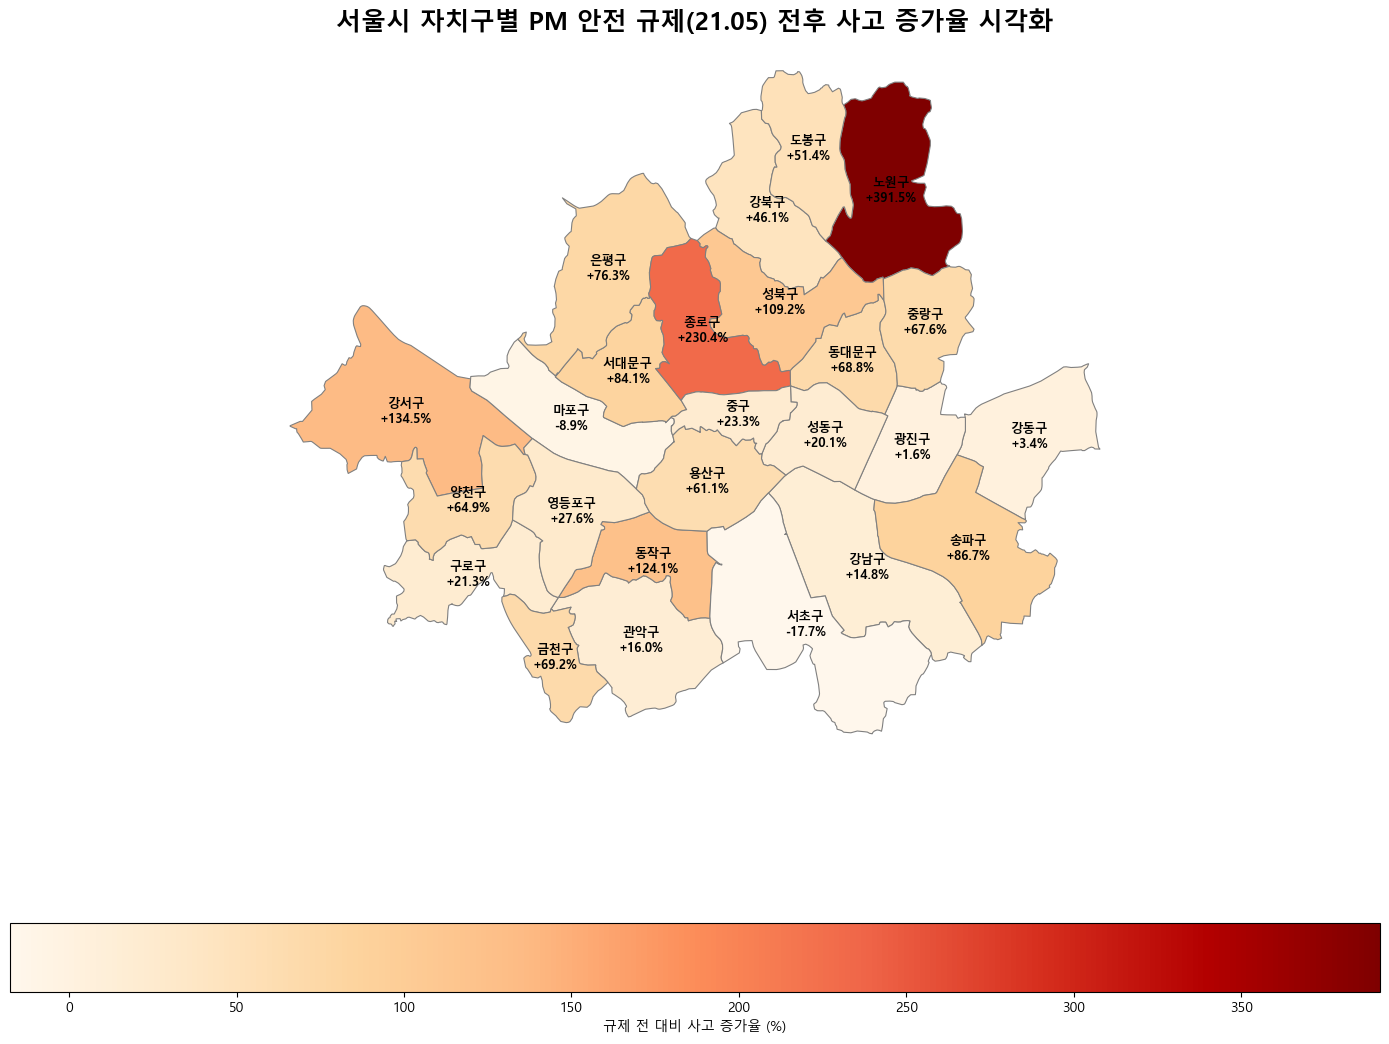

In [8]:
# 단계구분도(Choropleth Map) 시각화
fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# 사고가 증가한 것을 경고의 의미로 붉은색 계열(OrRd)로 표현
merged_map_df.plot(
    column='사고증가율(%)', 
    cmap='OrRd', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='0.5', 
    legend=True,
    legend_kwds={'label': "규제 전 대비 사고 증가율 (%)", 'orientation': "horizontal"},
    missing_kwds={'color': 'lightgrey', 'label': '데이터 없음'} # 데이터가 없는 구역 처리
)

for idx, row in merged_map_df.iterrows():
    if pd.notna(row['사고증가율(%)']):
        label_text = f"{row['sggnm']}\n{row['사고증가율(%)']:+.1f}%"
        centroid = row['geometry'].centroid
        
        ax.annotate(text=label_text,
                    xy=(centroid.x, centroid.y),
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=9,
                    fontweight='bold',
                    color='black')

ax.axis('off')
plt.title('서울시 자치구별 PM 안전 규제(21.05) 전후 사고 증가율 시각화', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

- 규제 전후 사고 증가율(%)을 보면 노원구, 종로구, 강서구 등 **주거 밀집 지역이나 외곽 지역에서 폭발적으로 증가했습니다.**

- 반면, **마포구, 서초구는 오히려 감소했습니다.**

****

#### **분석 3-1: 서울시 자치구별 PM 안전 규제(21.05) 전후 치명률 변화 시각화**

In [9]:
# 데이터 분리
df_before = df_acc[df_acc['연월'] < '2021-05-01']
df_after = df_acc[df_acc['연월'] >= '2021-05-01']

# 자치구별, 월별 '평균' 발생량 산출 
# 특정 연도 쏠림을 방지하기 위해 각 월의 평균적인 사고/사상자 규모를 먼저 구함
before_monthly = df_before.groupby(['자치구', '월'])[['PM_사고건수', '사망자수', '중상자수']].mean().reset_index()
after_monthly = df_after.groupby(['자치구', '월'])[['PM_사고건수', '사망자수', '중상자수']].mean().reset_index()

# 3. 1~12월의 평균 수치들을 합산 (계절성이 완벽히 통제된 '조정된 1년 치 총량' 도출)
before_adj_sum = before_monthly.groupby('자치구')[['PM_사고건수', '사망자수', '중상자수']].sum().reset_index()
after_adj_sum = after_monthly.groupby('자치구')[['PM_사고건수', '사망자수', '중상자수']].sum().reset_index()

# 4. 계절성 통제 기반 치명률(%) 계산
# 치명률 = (사망자수 + 중상자수) / PM사고건수 * 100
before_adj_sum['규제 전'] = ((before_adj_sum['사망자수'] + before_adj_sum['중상자수']) / before_adj_sum['PM_사고건수']) * 100
after_adj_sum['규제 후'] = ((after_adj_sum['사망자수'] + after_adj_sum['중상자수']) / after_adj_sum['PM_사고건수']) * 100

# 5. 규제 전/후 데이터 병합 및 치명률 변화(%p) 산출
fatal_compare = pd.merge(before_adj_sum[['자치구', '규제 전']], after_adj_sum[['자치구', '규제 후']], on='자치구', how='outer')

# 치명률 변화율(%p) 계산 (규제 후 - 규제 전)
fatal_compare['치명률_변화(%p)'] = fatal_compare['규제 후'] - fatal_compare['규제 전']

In [10]:
# 공간 데이터와 병합
merged_fatal_map = gu_geo_data.merge(fatal_compare, left_on='sggnm', right_on='자치구', how='outer')

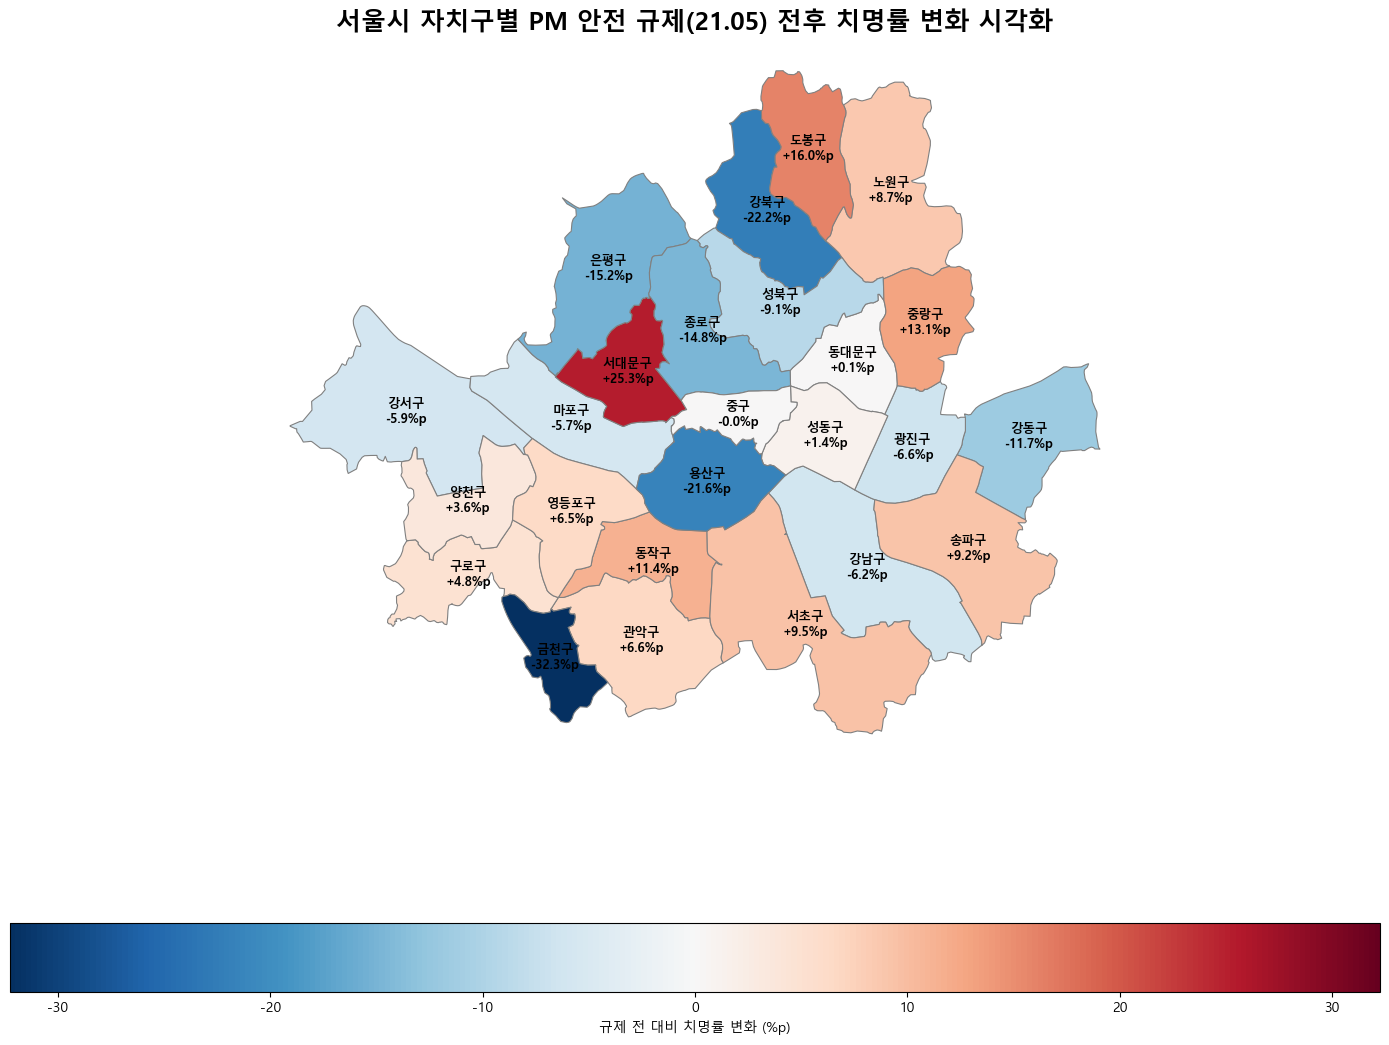

In [11]:
# 단계구분도 시각화
fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# 치명률 변화를 양수(증가)/음수(감소)가 명확한 색상으로 표현 (RdBu_r: 감소는 파랑, 증가는 빨강)
# 중심(0)을 맞추기 위해 vmin, vmax 설정
vmax = max(merged_fatal_map['치명률_변화(%p)'].max(), abs(merged_fatal_map['치명률_변화(%p)'].min()))
vmin = -vmax

merged_fatal_map.plot(
    column='치명률_변화(%p)', 
    cmap='RdBu_r', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='0.5', 
    legend=True,
    vmin=vmin, vmax=vmax,
    legend_kwds={'label': "규제 전 대비 치명률 변화 (%p)", 'orientation': "horizontal"}
)

# 텍스트 라벨 추가 (자치구 이름 및 치명률 변화량)
for idx, row in merged_fatal_map.iterrows():
    if pd.notna(row['치명률_변화(%p)']):
        # 증감에 따라 부호 표시
        sign = "+" if row['치명률_변화(%p)'] > 0 else ""
        label_text = f"{row['sggnm']}\n{sign}{row['치명률_변화(%p)']:.1f}%p"
        centroid = row['geometry'].centroid
        
        ax.annotate(text=label_text,
                    xy=(centroid.x, centroid.y),
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=9,
                    fontweight='bold',
                    color='black')

ax.axis('off')
plt.title('서울시 자치구별 PM 안전 규제(21.05) 전후 치명률 변화 시각화', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

- 유흥가가 밀집해 야간 치명률이 높을 것으로 예상했던 **마포구, 강남구, 종로구 등은 오히려 규제 이후 치명률이 유의미하게 감소했습니다.** 

- **서대문구, 도봉구, 중랑구 등 대학가 및 주거 지역은 치명률이 크게 상승**하며 붉은색을 띠고 있습니다.

#### **분석 3-2: 서울시 자치구별 PM 사고 건수 및 치명률 변화 교차 검증**
서울시 전체로 보면 PM 사고 건수가 꽤 많지만, 이를 25개 자치구로 잘게 쪼개면, 사고 건수(모수)가 너무 작아져 결과물의 신뢰도가 크게 떨어질 수 있습니다.

통계적 검정력이 부족해졌는지 확인하기 위해 교차 검증을 실시해봅니다.

In [12]:
# 규제 전 데이터 가져오기 (컬럼명 직관적으로 변경)
df_before_check = before_adj_sum[['자치구', 'PM_사고건수', '규제 전']].rename(
    columns={'PM_사고건수': '규제전_사고건수', '규제 전': '규제전_치명률(%)'}
)

# 규제 후 데이터 가져오기 (컬럼명 직관적으로 변경)
df_after_check = after_adj_sum[['자치구', 'PM_사고건수', '규제 후']].rename(
    columns={'PM_사고건수': '규제후_사고건수', '규제 후': '규제후_치명률(%)'}
)

In [13]:
# 데이터 병합 (자치구 기준)
df_check = pd.merge(df_before_check, df_after_check, on='자치구', how='outer')

In [14]:
# 치명률 변화(%p) 및 총 사고건수 추가
df_check['치명률_변화(%p)'] = df_check['규제후_치명률(%)'] - df_check['규제전_치명률(%)']
df_check['총_사고건수'] = df_check['규제전_사고건수'] + df_check['규제후_사고건수']

In [15]:
# 치명률 변화폭(절댓값)이 큰 순서대로 정렬하여 모수의 함정 확인
df_check['변화폭_절댓값'] = df_check['치명률_변화(%p)'].abs()
df_check_sorted = df_check.sort_values(by='변화폭_절댓값', ascending=False).drop(columns=['변화폭_절댓값'])

print("=== 자치구별 PM 사고 건수 및 치명률 변화 교차 검증 ===")
display(df_check_sorted.round(1).reset_index(drop=True))

=== 자치구별 PM 사고 건수 및 치명률 변화 교차 검증 ===


,자치구,규제전_사고건수,규제전_치명률(%),규제후_사고건수,규제후_치명률(%),치명률_변화(%p),총_사고건수
0,금천구,8.7,53.8,14.7,21.6,-32.3,23.3
1,서대문구,7.3,6.8,13.5,32.1,25.3,20.8
2,강북구,8.5,47.1,12.4,24.8,-22.2,20.9
3,용산구,4.5,63.0,7.2,41.4,-21.6,11.8
4,도봉구,6.2,13.5,9.3,29.5,16.0,15.5
5,은평구,9.8,44.1,17.3,28.8,-15.2,27.2
6,종로구,4.7,32.1,15.4,17.3,-14.8,20.1
7,중랑구,11.3,17.6,19.0,30.7,13.1,30.3
8,강동구,14.8,42.7,15.3,31.0,-11.7,30.2
9,동작구,9.0,16.7,20.2,28.1,11.4,29.2


앞서 우려했던 현상이 데이터에 그대로 나타나고 있음을 아주 명확하게 확인할 수 있습니다.

표의 최상단(치명률 변화폭 15%p 이상)에 위치한 금천구, 서대문구, 강북구, 용산구, 도봉구의 공통점은 총 사고 건수가 10~20건대 수준으로 서울시 최하위권이라는 점입니다.

이 지역들은 지형적 특성이나 인구 구조상 PM 이용 자체가 적은 곳입니다. **1~2건의 사고 추가 발생 여부에 따라 비율(%p)이 20~30%p씩 요동치는 것일 뿐, 이 지역이 규제 이후 확연히 위험해졌다거나 안전해졌다고 확언하기는 어렵습니다.**

#### **분석 3-3: 서울시 자치구별 PM 사고 건수 및 치명률 변화 교차 검증**

금천구의 치명률 15%p 증가(*각 자치구의 급격한 변동률*)가 우연히 발생한 것인지, 통계적으로 진짜 의미 있는 변화인지 **카이제곱 검정(Chi-square test) 또는 피셔의 정확 검정(Fisher's exact test)을 통해 p-value를 계산**합니다.

In [16]:
# 검정 결과를 저장할 리스트
stat_results = []

for index, row in before_adj_sum.iterrows():
    gu_name = row['자치구']
    
    # 규제 전후 데이터 추출
    before_row = before_adj_sum[before_adj_sum['자치구'] == gu_name].iloc[0]
    after_row = after_adj_sum[after_adj_sum['자치구'] == gu_name].iloc[0]
    
    # 규제 전: 전체 사고건수, 사상자(사망+중상), 비사상자(전체-사상자)
    before_total = before_row['PM_사고건수']
    before_fatal = before_row['사망자수'] + before_row['중상자수']
    before_non_fatal = before_total - before_fatal
    
    # 규제 후
    after_total = after_row['PM_사고건수']
    after_fatal = after_row['사망자수'] + after_row['중상자수']
    after_non_fatal = after_total - after_fatal
    
    # 2x2 분할표(Contingency Table) 생성
    # [[규제 전 치명상, 규제 전 비치명상],
    #  [규제 후 치명상, 규제 후 비치명상]]
    table = np.array([[before_fatal, before_non_fatal],
                      [after_fatal, after_non_fatal]])
    
    # 소수점 데이터(조정된 평균 합산)이므로, 검정을 위해 반올림하여 정수형으로 변환
    table_int = np.round(table).astype(int)
    
    # 카이제곱 검정 시도
    chi2, p_val, dof, expected = stats.chi2_contingency(table_int, correction=False)
    
    # 기대빈도 중 하나라도 5 미만이면 피셔의 정확 검정(Fisher's exact test) 사용
    if np.any(expected < 5):
        test_method = "Fisher's Exact"
        _, p_val = stats.fisher_exact(table_int)
    else:
        test_method = "Chi-Square"
        
    stat_results.append({
        '자치구': gu_name,
        '검정방법': test_method,
        'p-value': p_val,
        '유의미함(p<0.05)': p_val < 0.05
    })

In [17]:
# 결과를 데이터프레임으로 변환하고 기존 fatal_compare와 병합
df_stats = pd.DataFrame(stat_results)
fatal_compare_final = pd.merge(fatal_compare, df_stats, on='자치구')

In [18]:
# 치명률 변화가 큰 순서대로 정렬하여 출력
fatal_compare_final = fatal_compare_final.sort_values(by='치명률_변화(%p)', ascending=False)
display(fatal_compare_final)

# 통계적으로 유의미한(p<0.05) 자치구만 따로 필터링해서 확인
significant_gu = fatal_compare_final[fatal_compare_final['유의미함(p<0.05)'] == True]
print("\n[통계적으로 치명률 변화가 유의미한(p<0.05) 자치구]")
display(significant_gu)

,자치구,규제 전,규제 후,치명률_변화(%p),검정방법,p-value,유의미함(p<0.05)
13,서대문구,6.818182,32.098765,2.528058e+01,Fisher's Exact,0.248710,False
9,도봉구,13.513514,29.464286,1.595077e+01,Fisher's Exact,1.000000,False
24,중랑구,17.647059,30.701754,1.305470e+01,Fisher's Exact,0.672195,False
11,동작구,16.666667,28.099174,1.143251e+01,Fisher's Exact,1.000000,False
14,서초구,27.234043,36.692506,9.458464e+00,Chi-Square,0.405007,False
17,송파구,21.739130,30.966240,9.227109e+00,Chi-Square,0.268509,False
8,노원구,14.634146,23.325062,8.690916e+00,Fisher's Exact,1.000000,False
4,관악구,21.311475,27.915194,6.603719e+00,Chi-Square,0.484423,False
19,영등포구,30.476190,36.940299,6.464108e+00,Chi-Square,0.647901,False
6,구로구,23.762376,28.571429,4.809052e+00,Fisher's Exact,1.000000,False



[통계적으로 치명률 변화가 유의미한(p<0.05) 자치구]


,자치구,규제 전,규제 후,치명률_변화(%p),검정방법,p-value,유의미함(p<0.05)


**모든 자치구의 v-value가 0.05 이상으로 나왔습니다.**

이는 **현재 확보된 데이터(사고 건수)만으로는 각 자치구별 치명률의 증감이 규제의 실제 효과인지, 아니면 우연한 변동인지 통계적으로 확언할 수 없다**는 뜻입니다.

#### **분석 1 ~ 3 결론**

**자치구 단위로 계속 쪼개서 분석을 이어가는 것은 신뢰도와 설득력이 떨어지므로, 공간 분석의 한계를 인정하고, '요인 분석'에 집중합니다.**

----

#### **분석 4: 규제 전후 주/야간 PM 관련 교통사고 건수 및 치명률 시각화**

규제 전후 특정 시간(주간/야간)에 PM 관련 교통사고 건수 및 치명률의 변화 효과가 집중되어 나타날 수 있습니다. `서울시_PM_교통사고_사고단위.csv` 데이터셋에서 주간과 야간으로 시간대를 나누어 분석을 진행합니다.

In [19]:
# 사고 단위 데이터 로드
df_incident = pd.read_csv("서울시 PM 교통사고 현황\서울시_PM_교통사고_사고단위.csv", encoding='utf-8')

In [20]:
# 연/월 정보 추출 및 규제여부 라벨링
df_incident['연월'] = pd.to_datetime(df_incident['연월'])
df_incident['월'] = df_incident['연월'].dt.month
df_incident['규제여부'] = np.where(df_incident['연월'] < '2021-05-01', '규제 전', '규제 후')

df_incident['사망자수'] = pd.to_numeric(df_incident['사망자수'], errors='coerce').fillna(0)
df_incident['중상자수'] = pd.to_numeric(df_incident['중상자수'], errors='coerce').fillna(0)

In [21]:
# 연월별(YYYY-MM), 주야간 사고/사상자 발생량 1차 집계
monthly_dn = df_incident.groupby(['규제여부', '주야', '연월', '월']).agg(
    사고건수=('사고ID', 'count'),  # 사고 건수 카운트
    사망자수=('사망자수', 'sum'),
    중상자수=('중상자수', 'sum')
).reset_index()

In [22]:
# 특정 연도/계절 쏠림 방지를 위한 월별(1~12월) 평균 산출
avg_monthly_dn = monthly_dn.groupby(['규제여부', '주야', '월']).agg(
    평균사고건수=('사고건수', 'mean'),
    평균사망자수=('사망자수', 'mean'),
    평균중상자수=('중상자수', 'mean')
).reset_index()

In [23]:
# 1~12월 평균 수치를 합산 -> 계절성이 완벽히 통제된 '조정된 1년 치 총량' 도출
adj_dn = avg_monthly_dn.groupby(['규제여부', '주야']).agg(
    사고건수=('평균사고건수', 'sum'),
    사망자수=('평균사망자수', 'sum'),
    중상자수=('평균중상자수', 'sum')
).reset_index()

In [24]:
# 계절성 통제 기반 치명률(%) 계산
adj_dn['치명률(%)'] = (
    (adj_dn['사망자수'] + adj_dn['중상자수']) / 
    adj_dn['사고건수']) * 100

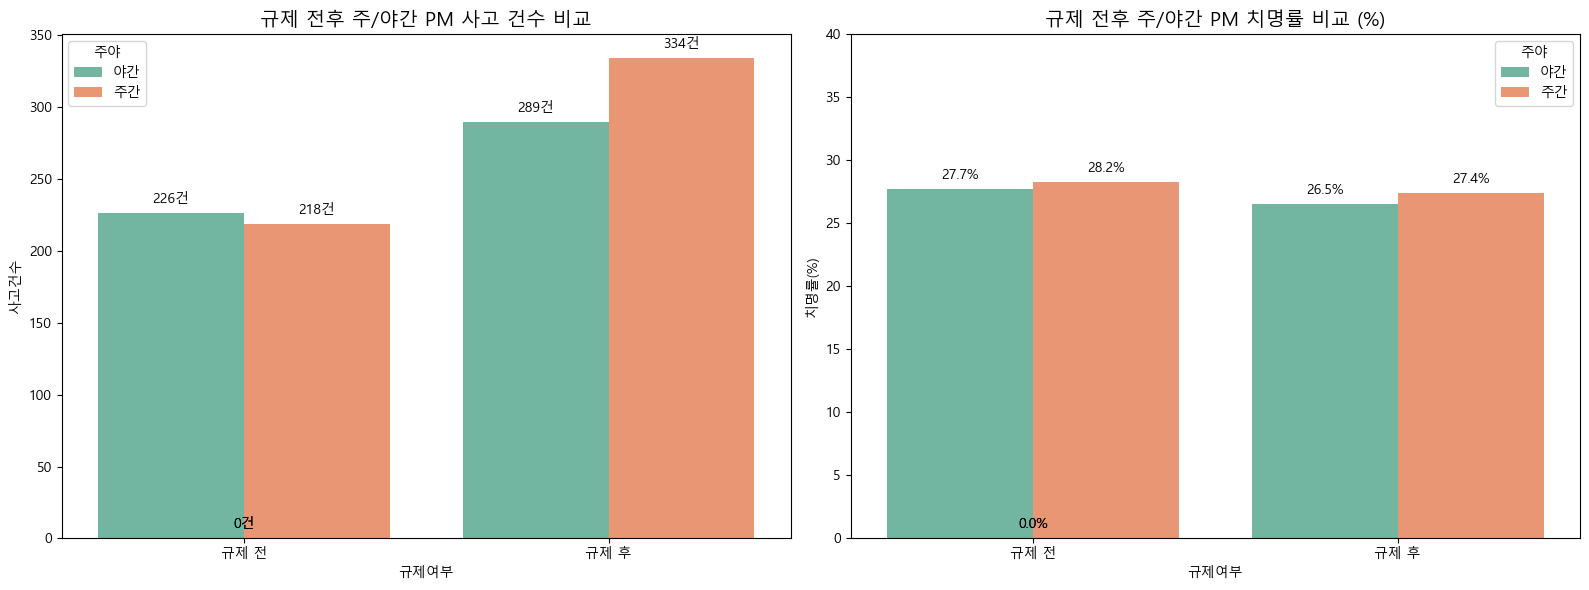

In [25]:
# 주야간 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 순서 고정
order_list = ['규제 전', '규제 후']

# 그래프 1: 주야간 사고 건수 비교
sns.barplot(data=adj_dn, x='규제여부', y='사고건수', hue='주야', ax=axes[0], order=order_list, palette='Set2')
axes[0].set_title('규제 전후 주/야간 PM 사고 건수 비교', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}건", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# 그래프 2: 주야간 치명률 비교
sns.barplot(data=adj_dn, x='규제여부', y='치명률(%)', hue='주야', ax=axes[1], order=order_list, palette='Set2')
axes[1].set_title('규제 전후 주/야간 PM 치명률 비교 (%)', fontsize=14)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.ylim(0, 40)
plt.tight_layout()
plt.show()

- **사고 발생량 역전(야간 -> 주간)**
  - 규제 전에는 야간(505건)과 주간(487건)이 비슷했지만, 규제 후에는 주간(1260건)이 야간(1094건)을 크게 추월했습니다.

- **치명률 변화**
  - 야간과 주간 모두 규제 전보다 PM 교통사고 치명률이 최대 1.2% 낮아졌습니다.

****

#### **분석 5: 규제 전후 주간 사고 법규위반 비중 및 법규위반별 치명률 비교**
규제 이후 사고 및 치명률이 상승한 주간 사고 데이터를 기준으로, 법규위반 비중 및 법규위반별 치명률을 시각화하고 분석합니다.

이전의 바이올린 차트(Violinplot)는 가해자가 PM 사용자인 사고만을 시각화하였다면, 이번 분석 과정은 모든 PM 관련 사고를 시각화합니다.

In [ ]:
# 데이터 로드
df_incident = pd.read_csv("서울시 PM 교통사고 현황\서울시_PM_교통사고_사고단위.csv", 
                        encoding='utf-8')

In [27]:
# 주간 데이터 전처리 (월 정보 추가 포함)
df_incident['연월'] = pd.to_datetime(df_incident['연월'])
df_incident['월'] = df_incident['연월'].dt.month
df_incident['규제여부'] = np.where(df_incident['연월'] < '2021-05-01', '규제 전', '규제 후')

df_day = df_incident[df_incident['주야'] == '주간'].copy()

df_day['사망자수'] = pd.to_numeric(df_day['사망자수'], errors='coerce').fillna(0)
df_day['중상자수'] = pd.to_numeric(df_day['중상자수'], errors='coerce').fillna(0)

In [28]:
# 연월별(YYYY-MM), 법규위반별 발생량 1차 집계
monthly_viol = df_day.groupby(['규제여부', '법규위반', '연월', '월']).agg(
    사고건수=('사고ID', 'count'), 
    사망자수=('사망자수', 'sum'),
    중상자수=('중상자수', 'sum')
).reset_index()

In [29]:
# 월별 평균 산출로 계절성 통제
avg_monthly_viol = monthly_viol.groupby(['규제여부', '법규위반', '월']).agg(
    평균사고건수=('사고건수', 'mean'),
    평균사망자수=('사망자수', 'mean'),
    평균중상자수=('중상자수', 'mean')
).reset_index()

In [30]:
# 1~12월 수치 합산 (조정된 1년 치 총량)
adj_viol = avg_monthly_viol.groupby(['규제여부', '법규위반']).agg(
    사고건수=('평균사고건수', 'sum'),
    사망자수=('평균사망자수', 'sum'),
    중상자수=('평균중상자수', 'sum')
).reset_index()

In [31]:
# 비중(%) 및 치명률(%) 계산
# 비중 계산을 위해 규제 전/후별 전체 주간 사고건수 총합 구하기
total_by_reg = adj_viol.groupby('규제여부')['사고건수'].sum().reset_index(name='전체사고건수')
adj_viol = pd.merge(adj_viol, total_by_reg, on='규제여부')

adj_viol['비중(%)'] = (adj_viol['사고건수'] / adj_viol['전체사고건수']) * 100
adj_viol['치명률(%)'] = ((adj_viol['사망자수'] + adj_viol['중상자수']) / adj_viol['사고건수']) * 100

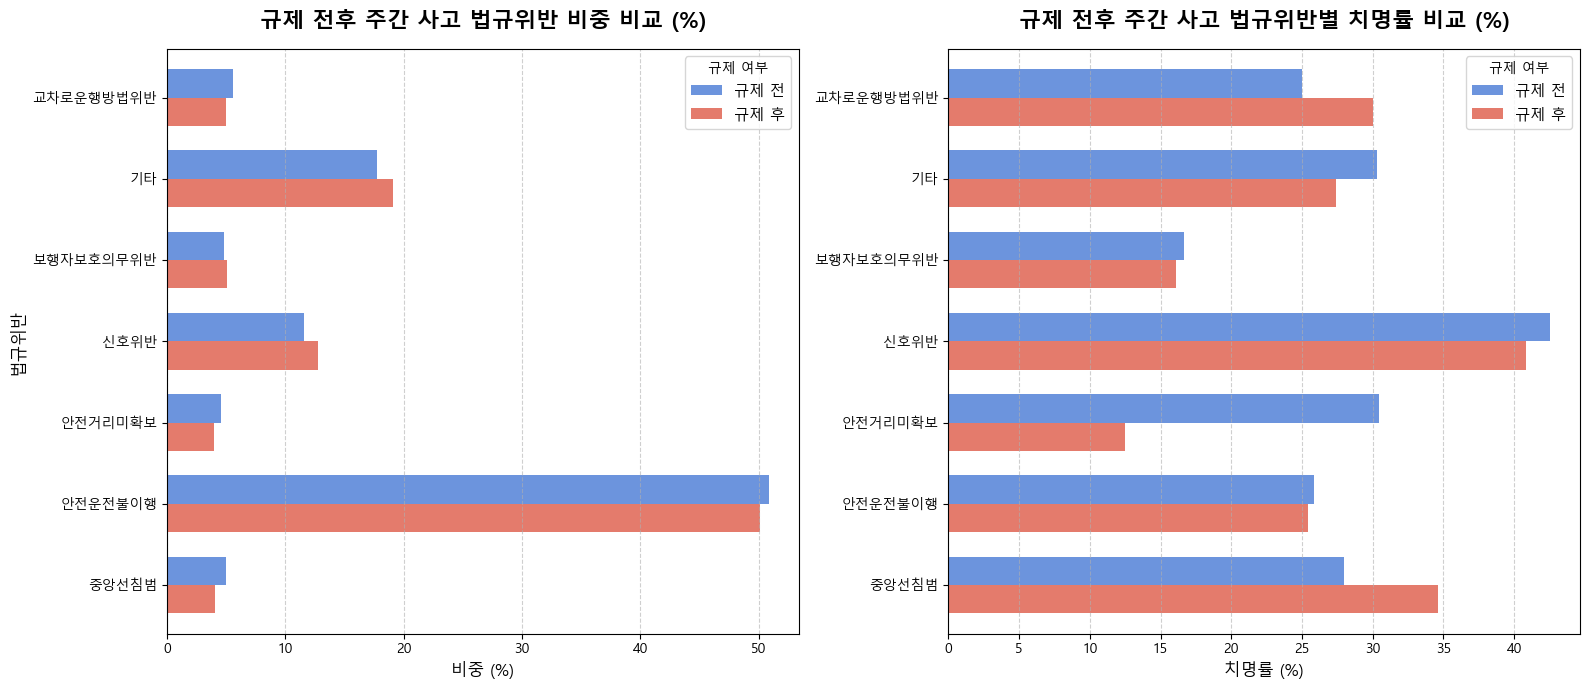

In [34]:
# 비교 형평성을 위해 '과속' 항목 제외
adj_viol_filtered = adj_viol[adj_viol['법규위반'] != '과속'].copy()

# 비중(%) 재계산 ('과속'을 뺀 나머지 전체를 100%로 두기)
total_by_reg_filtered = adj_viol_filtered.groupby('규제여부')['사고건수'].sum().reset_index(name='새_전체사고건수')
adj_viol_filtered = pd.merge(adj_viol_filtered, total_by_reg_filtered, on='규제여부')
adj_viol_filtered['비중(%)'] = (adj_viol_filtered['사고건수'] / adj_viol_filtered['새_전체사고건수']) * 100

# --- 시각화를 위한 데이터 구조 변경 (Pivot) ---
# X축(법규위반)과 범례(규제여부) 구조로 변환
props_pivot = adj_viol_filtered.pivot(index='법규위반', columns='규제여부', values='비중(%)')
fatality_pivot = adj_viol_filtered.pivot(index='법규위반', columns='규제여부', values='치명률(%)')

# '규제 전', '규제 후' 순서 고정
props_pivot = props_pivot[['규제 전', '규제 후']]
fatality_pivot = fatality_pivot[['규제 전', '규제 후']]

# --- 데이터 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # 가로로 넓게 배치

# 그래프 1: 규제 전후 주간 사고 법규위반 비중 비교 (barh 사용)
props_pivot.plot(kind='barh', ax=axes[0], color=['#5c88da', '#e26d5c'], width=0.7, alpha=0.9)

axes[0].set_title('규제 전후 주간 사고 법규위반 비중 비교 (%)', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('비중 (%)', fontsize=12) # X, Y축 라벨 위치 변경
axes[0].set_ylabel('법규위반', fontsize=12)
axes[0].legend(title='규제 여부', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.6) # 그리드 방향 변경

axes[0].invert_yaxis() # Y축 뒤집기(규제 전 그래프 바가 먼저 출력되도록 설정)

# 그래프 2: 규제 전후 법규위반별 치명률 비교 (barh 사용)
fatality_pivot.plot(kind='barh', ax=axes[1], color=['#5c88da', '#e26d5c'], width=0.7, alpha=0.9)

axes[1].set_title('규제 전후 주간 사고 법규위반별 치명률 비교 (%)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('치명률 (%)', fontsize=12) # X, Y축 라벨 위치 변경
axes[1].set_ylabel('') # 두 번째 그래프는 Y축 라벨 생략하여 깔끔하게
axes[1].legend(title='규제 여부', fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

axes[1].invert_yaxis() # Y축 뒤집기

plt.tight_layout()
plt.show()

- **규제 전후 주간 사고 법규위반 비중 비교**
  
  - 규제 전후 모두 '안전운전불이행'이 압도적인 1위(약 50~60% 수준)를 차지하고 있습니다.
  - 2021년 5월의 안전 규제(안전모 착용 의무화, 다인 탑승 금지 등)는 '운전자의 주행 습관' 자체를 교정하는 규제가 아니었습니다. 따라서 주간에 발생하는 사고의 절반 이상이 여전히 전방 주시 태만이나 운전 미숙과 같은 기본적 부주의에서 비롯되고 있음을 알 수 있습니다.
  
- **규제 전후 주간 사고 법규위반별 치명률 비교**

  - 사고 비중 2위인 '신호위반'의 치명률은 규제 이후 오히려 낮아졌습니다. 신호위반은 차량과의 충돌 등 큰 사고로 이어지기 쉬운데, '안전모 착용 의무화' 덕분에 최악의 상황(사망/중상)을 면한 케이스가 많아졌음을 시사합니다.
  - 반면, '교차로통행방법위반'과 '보행자보호의무위반'의 치명률은 규제 이후 치솟았습니다.

----
----

### **소결론**
PM(전동킥보드) 시장이 팽창하면서, 출퇴근이나 낮 시간대 단거리 이동용으로 인도를 주행하거나 골목 교차로를 튀어나오는 PM이 폭발적으로 늘어났습니다. 주간에는 차량 통행량과 보행자가 야간보다 훨씬 많고 복잡합니다. 따라서 복잡한 주간의 교차로에서 얽히거나(차량 vs PM), 붐비는 인도에서 보행자와 얽히는(보행자 vs PM) 사고가 발생했을 때, 그 충격량과 피해 규모가 커져 치명률(교차로통행방법위반, 보행자보호의무위반)이 급증했다고 해석할 수 있습니다.